In [1]:
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path

import scarf
from scarf.agent import (
    AgentOrchestrator,
    AgentRunConfig,
    AutomatedWorkflowConfig,
    AutomatedWorkflowRequest,
    DecisionSelection,
    generate_agent_report,
    load_agent_report,
    load_agent_workflow,
)
from scarf.agent.orchestrator import artifact_model_to_ref

scarf.configure_output(level="WARNING", progress=False)

source_path = scarf.cytebase.connect("scarf_docs").download(
    "tenx_5K_pbmc_rnaseq/data.h5",
    destination="scarf_datasets",
)[0]
zarr_path = source_path.with_name("agent_workflow.zarr")

study_context = (
    "This is a human 10x Genomics 5K PBMC 3-prime gene-expression dataset "
    "from peripheral blood collected from one healthy donor. The goal is "
    "unsupervised identification and characterization of the major immune-cell "
    "populations. No treatment comparison, technical batch covariate, paired "
    "modality, or independent replication metadata is available. Do not invent "
    "absent design variables or report treatment effects."
)

{"source": source_path.name, "destination": zarr_path.name}

Downloading bucket files: 18098007 / 18098007 complete

Downloading bytes: 18098007 / 18098007 complete

{'source': 'data.h5', 'destination': 'agent_workflow.zarr'}

In [2]:
import json
from typing import Any

from pydantic_ai.messages import (
    ModelMessage,
    ModelResponse,
    ToolCallPart,
    ToolReturnPart,
)
from pydantic_ai.models.function import AgentInfo, FunctionModel

from scarf.agent.biological_interpretation import (
    BiologicalInterpretationReport,
    ClusterCompositionEvidence,
    ClusterInterpretation,
    ClusterMarkerBatchEvidence,
)
from scarf.agent.data_enrichment import (
    AssayFeatureInspectionBatch,
    DataEnrichmentReport,
    FeatureSelectionPolicy,
    StudyContextSummary,
)
from scarf.agent.experimental_context import (
    BatchCorrectionPlan,
    CovariateEvidence,
    ExperimentalContextDecision,
)

def _prompt_text(messages: list[ModelMessage]) -> str:
    values = []
    for message in messages:
        for part in message.parts:
            content = getattr(part, "content", None)
            if isinstance(content, str):
                values.append(content)
            elif isinstance(content, tuple):
                values.extend(item for item in content if isinstance(item, str))
    return "\n".join(values)


def _tool_result(
    messages: list[ModelMessage],
    tool_name: str,
    model_type: Any,
) -> Any:
    for message in reversed(messages):
        for part in reversed(message.parts):
            if isinstance(part, ToolReturnPart) and part.tool_name == tool_name:
                if isinstance(part.content, model_type):
                    return part.content
                if isinstance(part.content, str):
                    return model_type.model_validate_json(part.content)
                return model_type.model_validate(part.content)
    raise AssertionError(f"Missing tool return {tool_name!r}")


def _tool_call(name: str, args: dict[str, Any] | None = None) -> ModelResponse:
    return ModelResponse(parts=[ToolCallPart(tool_name=name, args=args or {})])


def _structured_output(info: AgentInfo, value: Any) -> ModelResponse:
    payload = value.model_dump() if hasattr(value, "model_dump") else value
    return _tool_call(info.output_tools[0].name, payload)


def _scripted_workflow_model() -> tuple[FunctionModel, dict[str, int]]:
    state = {
        "enrichment": 0,
        "context": 0,
        "parameter": 0,
        "biology": 0,
        "requests": 0,
    }

    async def reply(
        messages: list[ModelMessage],
        info: AgentInfo,
    ) -> ModelResponse:
        state["requests"] += 1
        tools = {tool.name for tool in info.function_tools}

        if "inspect_assay_features_batch" in tools or state["enrichment"] == 1:
            if state["enrichment"] == 0:
                state["enrichment"] = 1
                return _tool_call("inspect_assay_features_batch")

            batch = _tool_result(
                messages,
                "inspect_assay_features_batch",
                AssayFeatureInspectionBatch,
            )
            policies = []
            for inspection in batch.inspections:
                species_observed = inspection.species != "unknown"
                policy_evidence = list(inspection.evidenceIds)
                if not species_observed:
                    policy_evidence.append("context:study")
                policies.append(
                    FeatureSelectionPolicy(
                        assay=inspection.assay,
                        species=(
                            inspection.species
                            if species_observed
                            else "homo_sapiens"
                        ),
                        speciesConfidence="high" if species_observed else "medium",
                        speciesRationale=(
                            inspection.speciesReason
                            or "The exact study paragraph identifies a human sample."
                        ),
                        excludeFamilies=[
                            family.family
                            for family in inspection.families
                            if family.count > 0 and family.defaultExclude is True
                        ],
                        protectFamilies=[
                            family.family
                            for family in inspection.families
                            if family.count > 0 and family.defaultExclude is False
                        ],
                        rationale=(
                            "Exclude observed technical families and preserve "
                            "observed protected families."
                        ),
                        evidenceIds=list(dict.fromkeys(policy_evidence)),
                    )
                )
            state["enrichment"] = 2
            return _structured_output(
                info,
                DataEnrichmentReport(
                    status="done",
                    studyContextSummary=StudyContextSummary(
                        organismReferences=["human"],
                        tissueReferences=["peripheral blood"],
                        experimentalReferences=[
                            "10x Genomics 5K PBMC 3-prime gene-expression dataset"
                        ],
                        analysisIntentReferences=[
                            "unsupervised identification and characterization of "
                            "the major immune-cell populations"
                        ],
                    ),
                    policies=policies,
                ),
            )

        if tools.intersection(
            {
                "inspect_cell_covariates",
                "analyze_experimental_design",
                "score_current_representation",
            }
        ) or state["context"] in {1, 2}:
            if state["context"] == 0:
                state["context"] = 1
                return _tool_call("inspect_cell_covariates")
            if state["context"] == 1:
                state["context"] = 2
                return _tool_call(
                    "analyze_experimental_design",
                    {
                        "column_domains": {},
                        "coefficients_of_interest": [],
                        "units_of_inference": {},
                        "batch_columns": [],
                    },
                )

            design = _tool_result(
                messages,
                "analyze_experimental_design",
                CovariateEvidence,
            )
            profile = next(
                value
                for value in design.qcProfiles
                if value.action == "skip"
            )
            evidence_id = profile.evidenceId
            state["context"] = 3
            return _structured_output(
                info,
                ExperimentalContextDecision(
                    batchCorrection=BatchCorrectionPlan(
                        action="skip",
                        rationale="No trusted technical batch column was supplied.",
                        evidenceIds=[evidence_id],
                    ),
                    rationale="No experimental covariates were supplied.",
                    evidenceIds=[evidence_id],
                ),
            )

        if tools.intersection(
            {"inspect_cluster_composition", "inspect_cluster_markers_batch"}
        ) or state["biology"]:
            if state["biology"] == 0:
                state["biology"] = 1
                return _tool_call("inspect_cluster_composition")
            if state["biology"] == 1:
                composition = _tool_result(
                    messages,
                    "inspect_cluster_composition",
                    ClusterCompositionEvidence,
                )
                state["biology"] = 2
                return _tool_call(
                    "inspect_cluster_markers_batch",
                    {"cluster_ids": list(composition.clusterCounts)},
                )

            marker_batch = _tool_result(
                messages,
                "inspect_cluster_markers_batch",
                ClusterMarkerBatchEvidence,
            )
            interpretations = []
            for cluster in marker_batch.clusters:
                if cluster.evidenceId and cluster.markers:
                    marker = cluster.markers[0]
                    marker_name = marker.featureName or marker.featureId
                    interpretations.append(
                        ClusterInterpretation(
                            clusterId=cluster.clusterId,
                            proposedIdentity=f"{marker_name}-high RNA state",
                            identityIsHypothesis=True,
                            confidence="low",
                            rationale=(
                                "The returned marker panel is led by "
                                f"{marker_name}."
                            ),
                            evidenceIds=[cluster.evidenceId],
                        )
                    )
            state["biology"] = 3
            return _structured_output(
                info,
                BiologicalInterpretationReport(
                    status="done",
                    clusterInterpretations=interpretations,
                    evidenceIds=[item.evidenceIds[0] for item in interpretations],
                    limitations=[
                        "The scripted documentation model returns marker-linked "
                        "hypotheses, not validated cell identities."
                    ],
                    stopReason=(
                        "Every cluster with returned marker evidence was reviewed."
                    ),
                ),
            )

        prompt = _prompt_text(messages)
        if any(
            tool.parameters_json_schema.get("title")
            == "AnalysisVisualAdjudication"
            for tool in info.output_tools
        ):
            payload, _ = json.JSONDecoder().raw_decode(prompt[prompt.index("{") :])
            return _structured_output(
                info,
                {
                    "status": "acceptable",
                    "selectedCandidateId": payload["selectedCandidateId"],
                    "rationale": (
                        "The bounded diagnostic board agrees with the registered "
                        "numeric evidence."
                    ),
                },
            )

        decision, _ = json.JSONDecoder().raw_decode(prompt[prompt.index("{") :])
        evidence_by_class = {}
        evidence_class_by_id = {}
        for item in decision["evidence"]:
            evidence_by_class.setdefault(
                item["evidenceClass"],
                item["evidenceId"],
            )
            evidence_class_by_id[item["evidenceId"]] = item["evidenceClass"]
        preferred = decision.get("metricPreferredOptionId")
        selected = (
            next(
                option
                for option in decision["options"]
                if option["optionId"] == preferred
            )
            if preferred is not None
            else next(
                option
                for option in decision["options"]
                if option["status"] in {"apply", "skip"}
            )
        )
        evidence_ids = list(selected.get("requiredEvidenceIds", []))
        cited_classes = {
            evidence_class_by_id[evidence_id] for evidence_id in evidence_ids
        }
        for evidence_class in selected["requiredEvidenceClasses"]:
            if evidence_class not in cited_classes:
                evidence_ids.append(evidence_by_class[evidence_class])
        state["parameter"] += 1
        return _structured_output(
            info,
            DecisionSelection(
                selectedOptionId=selected["optionId"],
                evidenceIds=evidence_ids,
                rationale="Select the registered metric-preferred option.",
                confidence="high",
            ),
        )

    return FunctionModel(reply), state

In [3]:
model, model_state = _scripted_workflow_model()
config = AutomatedWorkflowConfig(
    inputPolicy="unattended",
    primaryInitialCandidates=1,
    secondaryInitialCandidates=1,
    maxRefinedCandidatesPerAssay=0,
    maxHarmonyCandidatesPerAssay=0,
    integrationResolutionCandidates=1,
    maxCandidateBranches=1,
    minClusterCells=2,
    agentRunConfig=AgentRunConfig(
        requestLimit=5,
        toolCallLimit=5,
    ),
)
orchestrator = AgentOrchestrator(model, config=config)
request = AutomatedWorkflowRequest(
    sourcePath=str(source_path),
    zarrPath=str(zarr_path),
    studyContext=study_context,
    studyObjective="Discover stable major immune-cell populations.",
    primaryAssay="RNA",
    markerAssay="RNA",
    analysisAssays=["RNA"],
    ingestDirections={"overwrite": True, "defaultAssay": "RNA"},
)

{
    "initial_candidates": config.primaryInitialCandidates,
    "refinement_candidates": config.maxRefinedCandidatesPerAssay,
    "harmony_candidates": config.maxHarmonyCandidatesPerAssay,
    "input_policy": config.inputPolicy,
}

{'initial_candidates': 1,
 'refinement_candidates': 0,
 'harmony_candidates': 0,
 'input_policy': 'unattended'}

In [4]:
with redirect_stdout(StringIO()):
    result = orchestrator.run(request)

if (
    result.status != "completed"
    or result.finalAnalysis is None
    or result.preprocessingPlan is None
    or result.workflowRun is None
    or result.zarrPath is None
):
    raise RuntimeError(f"Unexpected workflow result: {result.status}, {result.notes}")

plan = result.preprocessingPlan
{
    "status": result.status,
    "stage": result.currentStage,
    "primary_assay": plan.primaryAssay,
    "marker_assay": plan.markerAssay,
    "cell_qc": plan.cellQc.action,
    "routes": [
        {
            "assay": assay.assay,
            "features": assay.featureMethod,
            "reduction": assay.reductionMethod,
        }
        for assay in plan.assays
    ],
}

{'status': 'completed',
 'stage': 'analysis_finalization',
 'primary_assay': 'RNA',
 'marker_assay': 'RNA',
 'cell_qc': 'skip',
 'routes': [{'assay': 'RNA', 'features': 'hvg', 'reduction': 'pca'}]}

In [5]:
persisted_workflow = load_agent_workflow(
    result.zarrPath,
    result.workflowRun.workflowRunId,
    workspace=result.workflowRun.workspace,
)

{
    "status": persisted_workflow.status,
    "stage": result.currentStage,
    "agent_reports": [ref.agentName for ref in result.reportReferences],
    "model_requests": model_state["requests"],
    "graph_method": result.finalAnalysis.graphMethod,
    "marker_assay": result.finalAnalysis.markerAssay,
}

{'status': 'completed',
 'stage': 'analysis_finalization',
 'agent_reports': ['data_enrichment',
  'experimental_context',
  'parameter_tuning'],
 'model_requests': 12,
 'graph_method': 'native',
 'marker_assay': 'RNA'}

In [6]:
reports = {
    reference.agentName: load_agent_report(result.zarrPath, reference)
    for reference in result.reportReferences
}
parameter_report = reports["parameter_tuning"]

candidate_metrics = []
for assay, assay_report in parameter_report.assayReports.items():
    for index, evaluation in enumerate(assay_report.evaluations, start=1):
        candidate_metrics.append(
            {
                "assay": assay,
                "candidate": index,
                "dimensions": evaluation.parameters.dimensions,
                "resolution": evaluation.parameters.leidenResolution,
                "neighbors": evaluation.parameters.neighborsK,
                "eligible": evaluation.eligible,
                "clusters": evaluation.metrics.nClusters,
                "smallest_cluster": evaluation.metrics.minClusterCells,
                "graph_silhouette": evaluation.metrics.graphSilhouetteMedian,
            }
        )

{
    "candidates": candidate_metrics,
    "stop_reason": parameter_report.stopReason,
    "report_statuses": {
        name: report.status for name, report in reports.items()
    },
}

{'candidates': [{'assay': 'RNA',
   'candidate': 1,
   'dimensions': 10,
   'resolution': 1.0,
   'neighbors': 21,
   'eligible': True,
   'clusters': 15,
   'smallest_cluster': 27,
   'graph_silhouette': 0.36498694993471886},
  {'assay': 'RNA',
   'candidate': 2,
   'dimensions': 20,
   'resolution': 1.0,
   'neighbors': 21,
   'eligible': True,
   'clusters': 11,
   'smallest_cluster': 30,
   'graph_silhouette': 0.3899432284072132},
  {'assay': 'RNA',
   'candidate': 3,
   'dimensions': 30,
   'resolution': 1.0,
   'neighbors': 21,
   'eligible': True,
   'clusters': 13,
   'smallest_cluster': 26,
   'graph_silhouette': 0.16811359562882475},
  {'assay': 'RNA',
   'candidate': 4,
   'dimensions': 50,
   'resolution': 1.0,
   'neighbors': 21,
   'eligible': True,
   'clusters': 12,
   'smallest_cluster': 28,
   'graph_silhouette': 0.2779521381867694},
  {'assay': 'RNA',
   'candidate': 5,
   'dimensions': 10,
   'resolution': 1.0,
   'neighbors': 21,
   'eligible': True,
   'clusters':

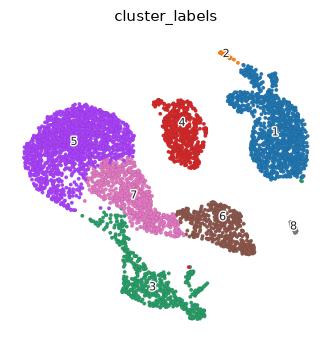

In [7]:
final = result.finalAnalysis
if (
    final.cellSelection is None
    or final.clusters is None
    or final.umap is None
    or final.markers is None
):
    raise RuntimeError("The completed final handoff is missing required artifacts")

final_store = scarf.DataStore(
    result.zarrPath,
    default_assay=final.primaryAssay,
    min_features_per_cell=-1,
    mito_pattern="",
    ribo_pattern="",
    zarr_mode="r",
    workspace=result.workflowRun.workspace,
    nthreads=2,
)
cell_selection_ref = artifact_model_to_ref(final.cellSelection)
cluster_ref = artifact_model_to_ref(final.clusters)
umap_ref = artifact_model_to_ref(final.umap)
marker_ref = artifact_model_to_ref(final.markers)

final_store.plots.embedding(
    layout=umap_ref,
    color_by=cluster_ref,
    legend_loc="on_data",
    frame="none",
)

In [8]:
marker_table = final_store.get_markers(
    marker=marker_ref,
    group_id=None,
    min_score=-1,
    min_frac_exp=-1,
)
marker_table.sort_values(
    ["group_id", "score"],
    ascending=[True, False],
).groupby("group_id", sort=True).head(2)[
    ["group_id", "feature_name", "score", "frac_exp"]
].head(12)

,group_id,feature_name,score,frac_exp
0,1,FPR1,0.97096,0.82675
1,1,TMEM176B,0.95601,0.87702
14391,2,IL3RA,0.89624,1.00000
14392,2,GAS6,0.89556,1.00000
28782,3,HIST1H2BG,0.35738,0.18953
28783,3,ANO9,0.35118,0.09386
43173,4,VPREB3,0.94331,0.76994
43174,4,IGHD,0.91314,0.74397
57564,5,LRRN3,0.79239,0.50154
57565,5,NOG,0.71040,0.23722


In [9]:
report_path = generate_agent_report(
    result.zarrPath,
    result.workflowRun.workflowRunId,
    workspace=result.workflowRun.workspace,
)
display_path = str(report_path.relative_to(Path(result.zarrPath).parent)).replace(
    result.workflowRun.workflowRunId,
    "<workflowRunId>",
)

{
    "report": display_path,
    "exists": report_path.is_file(),
    "final_artifact_kinds": {
        "selection": cell_selection_ref.kind,
        "clusters": cluster_ref.kind,
        "umap": umap_ref.kind,
        "markers": marker_ref.kind,
    },
}

{'report': 'agent_workflow.zarr/agents/runs/<workflowRunId>/report/index.html',
 'exists': True,
 'final_artifact_kinds': {'selection': 'cell_selection',
  'clusters': 'cluster_labels',
  'umap': 'embedding',
  'markers': 'marker_table'}}